In [1]:
import sys, json
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit

In [2]:
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))

TRAIN_PATH = BASE_DIR / "data" / "raw" / "train.csv"
TEST_PATH = BASE_DIR / "data" / "raw" / "hidden_test.csv"

df_train_raw = pd.read_csv(TRAIN_PATH, sep=';')
df_test_raw = pd.read_csv(TEST_PATH, sep=';')

FEATURE_COLS = ['DTC', 'RHOB', 'NPHI', 'DTS', 'BS', 'CALI']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(df_train_raw, groups=df_train_raw['WELL']))

df_dae_train = df_train_raw.iloc[train_idx].reset_index(drop=True)
df_dae_val = df_train_raw.iloc[val_idx].reset_index(drop=True)

In [3]:
from src import GeophysicalFeatureExtractor, DataCleansing
from src.models.baseline import Baseline
from src.models.rf_cb_optuna import RandomForest
from src.metrics import LithologyEvaluator

In [4]:
train_medians = df_dae_train[FEATURE_COLS].median()

raw_train_vals = df_dae_train[FEATURE_COLS].values
col_mean = np.nanmean(raw_train_vals, axis=0)
col_std = np.nanstd(raw_train_vals, axis=0)
col_std = np.where(col_std == 0, 1.0, col_std)

scaler = StandardScaler()
scaler.mean_ = col_mean
scaler.scale_ = col_std
scaler.var_ = col_std ** 2
scaler.n_features_in_ = len(FEATURE_COLS)

def make_inputs(df):
    obs_mask = ~df[FEATURE_COLS].isna().values
    filled = df[FEATURE_COLS].fillna(train_medians).values
    scaled = scaler.transform(filled)
    scaled_input = np.where(obs_mask, scaled, 0.0)
    return scaled_input, obs_mask.astype(np.float32), scaled

X_train_input, train_obs_mask, X_train_scaled_full = make_inputs(df_dae_train)
X_val_input, val_obs_mask, X_val_scaled_full = make_inputs(df_dae_val)
X_test_input, test_obs_mask, X_test_scaled_full = make_inputs(df_test_raw)

In [5]:
class DAEImputerModified(nn.Module):
    def __init__(self, input_dim, latent_dim=32):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.2),
            
            nn.Linear(128, latent_dim),
            nn.GELU(),
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            
            nn.Linear(64, input_dim),
        )
        
    def forward(self, x):
        return self.decoder(self.encoder(x))

In [6]:
def train_dae(model, X_scaled, observed_mask, X_val_scaled, val_observed_mask,
              feature_names, corruption_rate=0.3, epochs=50, batch_size=256, lr=1e-3,
              save_dir: Path = None):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    dataset = torch.utils.data.TensorDataset(
        torch.tensor(X_scaled, dtype=torch.float32),
        torch.tensor(observed_mask, dtype=torch.float32)
    )
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    history = {"train_loss": [], "val_loss": [], "val_loss_per_feature": []}
    x_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
    val_mask_t = torch.tensor(val_observed_mask, dtype=torch.float32)

    for epoch in range(1, epochs + 1):
        model.train()
        total_train_loss = 0.0
        for batch_x, batch_obs_mask in loader:
            noise_mask = (torch.rand_like(batch_x) > corruption_rate).float()
            input_mask = batch_obs_mask * noise_mask
            corrupted_x = batch_x * input_mask
            optimizer.zero_grad()
            reconstructed = model(corrupted_x)
            target_mask = batch_obs_mask * (1.0 - noise_mask)
            if target_mask.sum() == 0:
                continue
            loss = ((reconstructed - batch_x) ** 2 * target_mask).sum() / target_mask.sum()
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
        history["train_loss"].append(total_train_loss / len(loader))

        model.eval()
        with torch.no_grad():
            g = torch.Generator().manual_seed(42 + epoch)
            rand_noise = (torch.rand(x_val_t.shape, generator=g) > corruption_rate).float()
            corrupt_val = x_val_t * (val_mask_t * rand_noise)
            rec_val = model(corrupt_val)
            tgt_mask = val_mask_t * (1.0 - rand_noise)
            val_loss = (((rec_val - x_val_t) ** 2 * tgt_mask).sum() / tgt_mask.sum()).item()
            history["val_loss"].append(val_loss)

            per_feature = (((rec_val - x_val_t) ** 2 * tgt_mask).sum(dim=0) /
                           tgt_mask.sum(dim=0).clamp(min=1)).tolist()
            history["val_loss_per_feature"].append(per_feature)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:02d}/{epochs} | Train {history['train_loss'][-1]:.5f} | Val {val_loss:.5f}")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history["train_loss"], label="Train Loss", color="#2b5c8f")
    ax.plot(history["val_loss"], label="Val Loss", color="#d95f02", linestyle="--")
    ax.set_title("DAE Learning Curves"); ax.set_xlabel("Epoch"); ax.set_ylabel("Masked MSE")
    ax.legend(); ax.grid(alpha=0.4)

    if save_dir:
        save_dir = Path(save_dir); save_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_dir / "dae_loss_curve.png", dpi=150, bbox_inches="tight")
        with open(save_dir / "dae_history.json", "w") as f:
            json.dump(history, f, indent=2)
        torch.save(model.state_dict(), save_dir / "dae_weights.pt")
        final_per_feature = dict(zip(feature_names, history["val_loss_per_feature"][-1]))
        with open(save_dir / "dae_per_feature_val_loss.json", "w") as f:
            json.dump(final_per_feature, f, indent=2)
        print("Per-feature val MSE (последняя эпоха):", final_per_feature)

    plt.show()
    return history

Epoch 01/50 | Train 0.42597 | Val 0.38787
Epoch 10/50 | Train 0.36424 | Val 0.36950
Epoch 20/50 | Train 0.35790 | Val 0.36744
Epoch 30/50 | Train 0.35380 | Val 0.36929
Epoch 40/50 | Train 0.35264 | Val 0.36138
Epoch 50/50 | Train 0.34967 | Val 0.36503
Per-feature val MSE (последняя эпоха): {'DTC': 0.2931576669216156, 'RHOB': 0.3417511582374573, 'NPHI': 0.36921927332878113, 'DTS': 0.6083429455757141, 'BS': 0.3970939815044403, 'CALI': 0.3963562250137329}


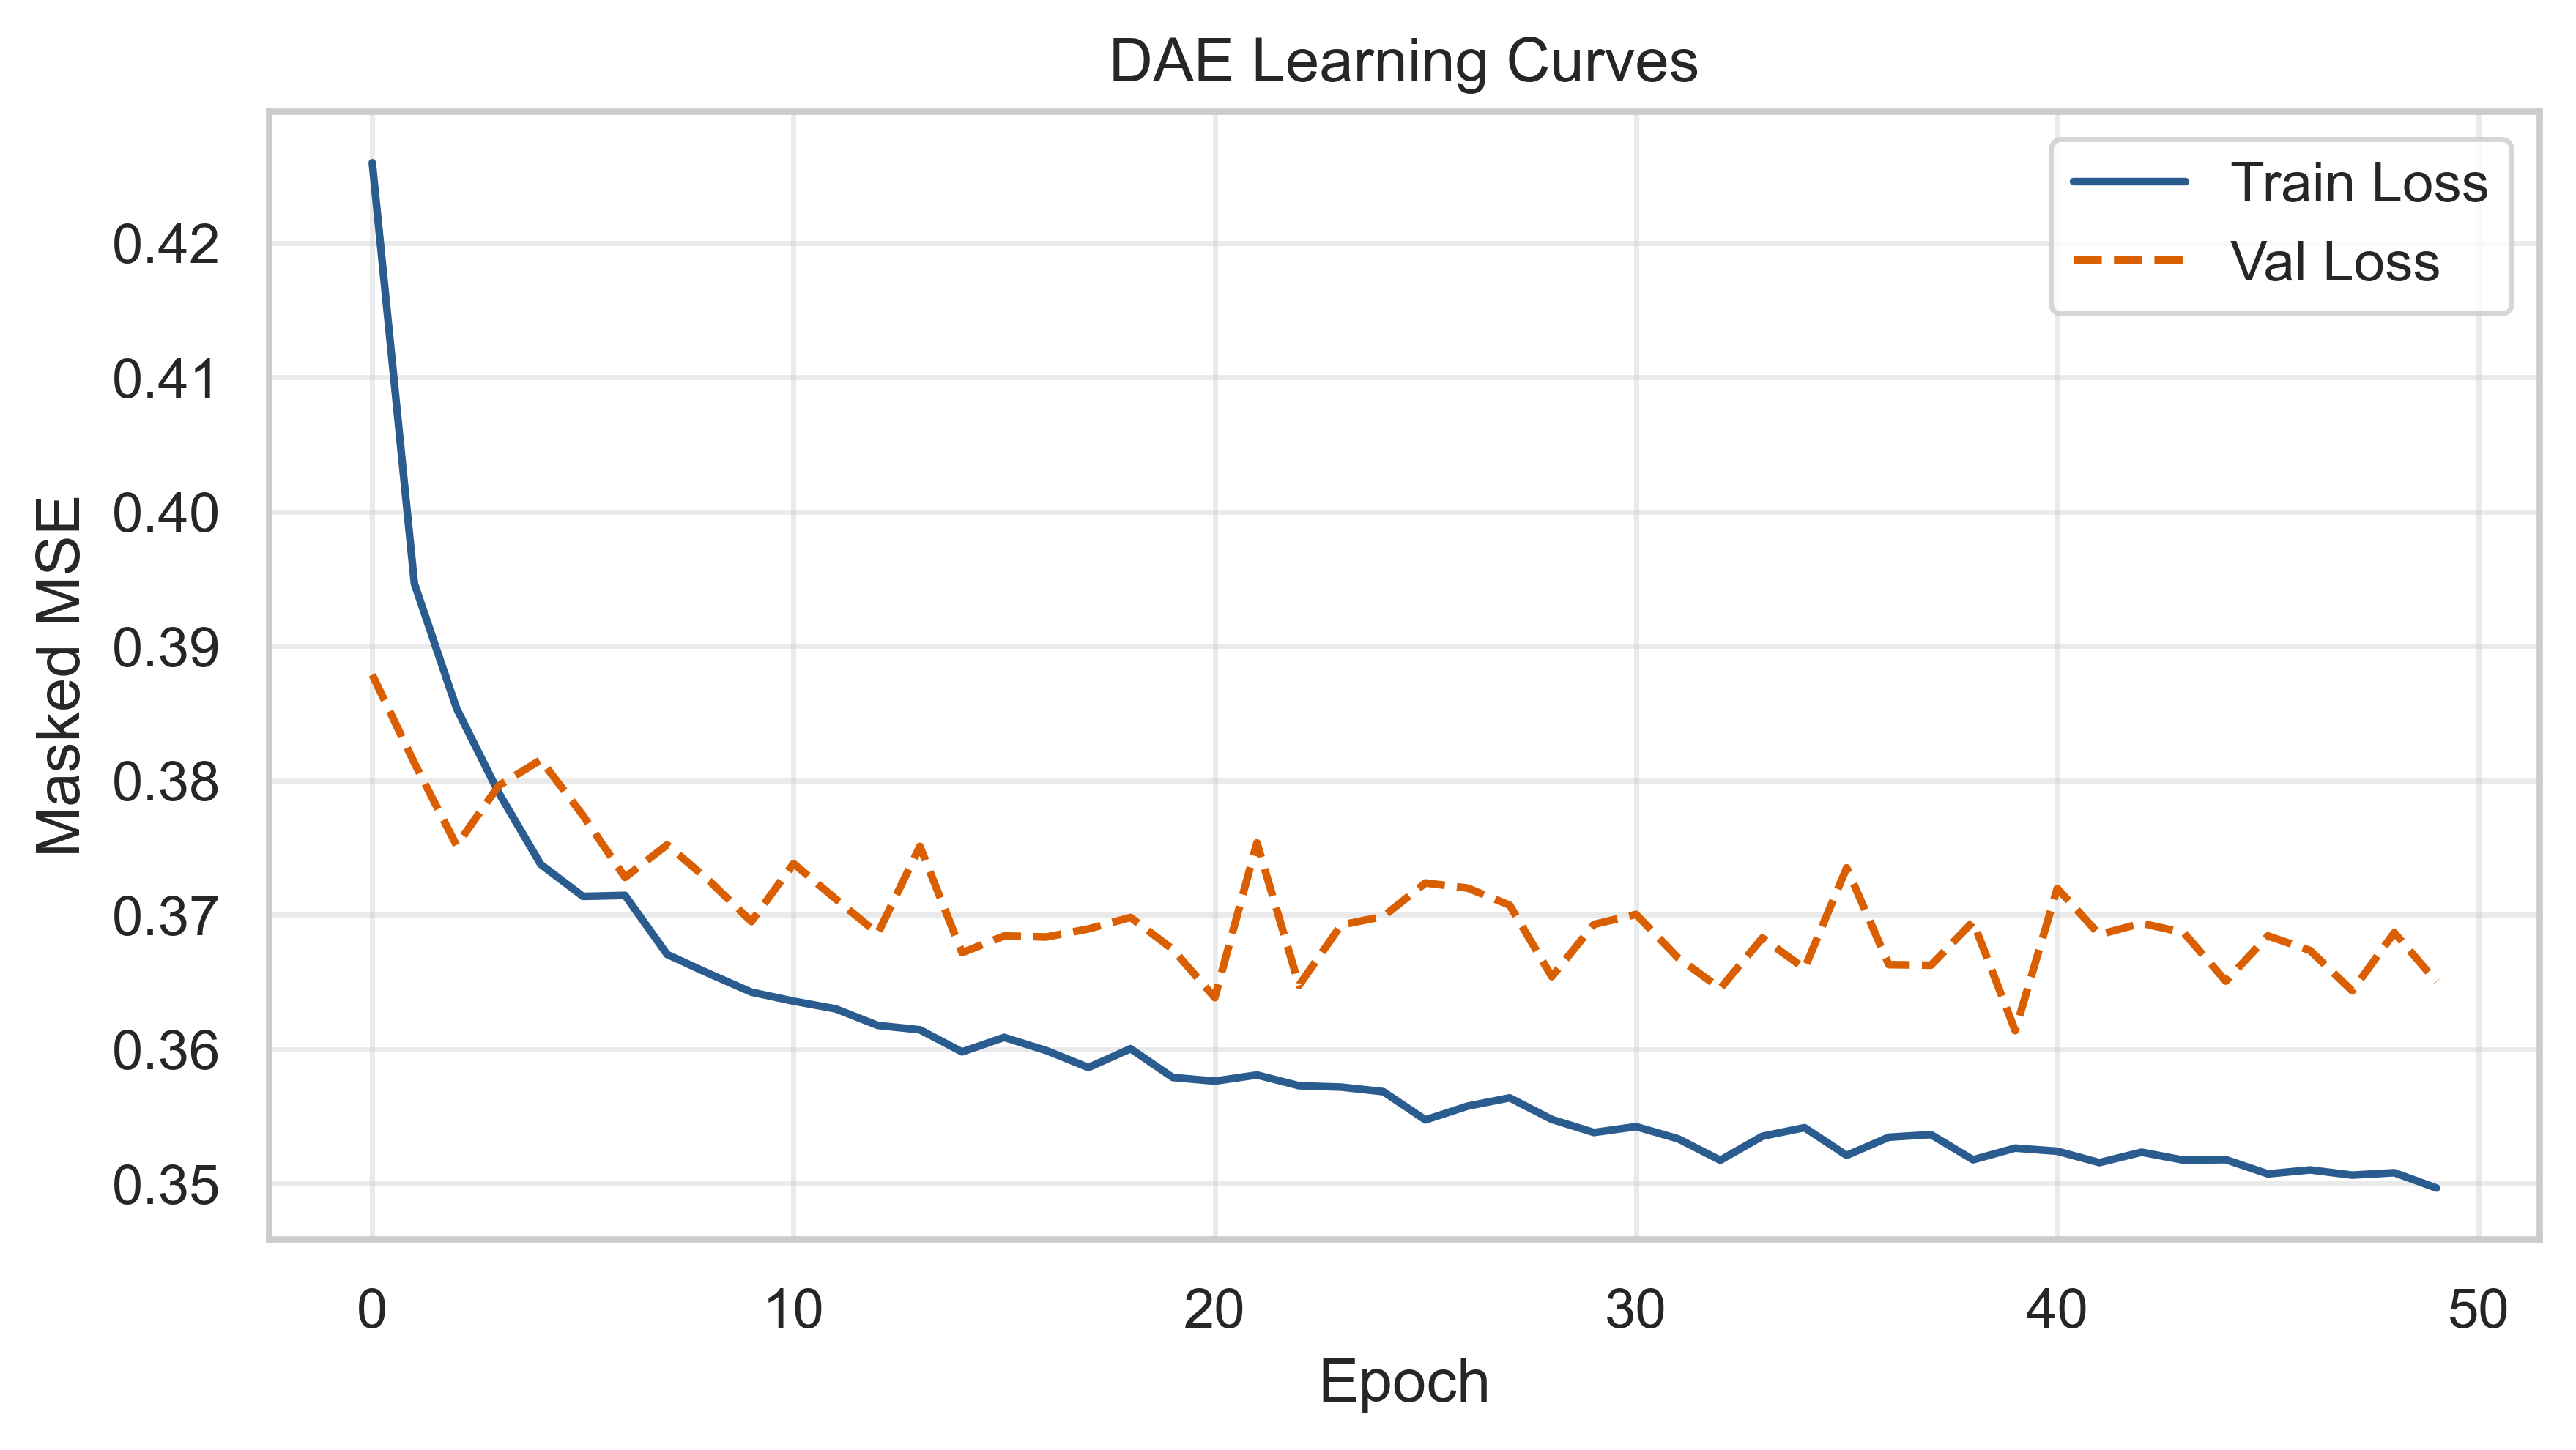

In [7]:
dae_model = DAEImputerModified(input_dim=len(FEATURE_COLS), latent_dim=32)
history = train_dae(
    dae_model, X_train_input, train_obs_mask, X_val_input, val_obs_mask,
    feature_names=FEATURE_COLS, epochs=50,
    save_dir=BASE_DIR / "reports" / "figures" / "dae_baseline",
)

In [8]:
def impute(model, X_scaled_input, obs_mask, X_scaled_full):
    model.eval()
    with torch.no_grad():
        rec = model(torch.tensor(X_scaled_input, dtype=torch.float32)).numpy()
    return np.where(obs_mask.astype(bool), X_scaled_full, rec)

def build_imputed_df(df_raw, scaled_input, obs_mask, scaled_full):
    imputed_scaled = impute(dae_model, scaled_input, obs_mask, scaled_full)
    imputed = scaler.inverse_transform(imputed_scaled)
    out = df_raw.copy()
    out[FEATURE_COLS] = imputed
    return out

df_train_dae = build_imputed_df(df_dae_train, X_train_input, train_obs_mask, X_train_scaled_full)
df_val_dae = build_imputed_df(df_dae_val, X_val_input, val_obs_mask, X_val_scaled_full)
df_test_dae = build_imputed_df(df_test_raw, X_test_input, test_obs_mask, X_test_scaled_full)

df_full_train_dae = pd.concat([df_train_dae, df_val_dae], ignore_index=True)

In [9]:
geo = GeophysicalFeatureExtractor()
cleaner = DataCleansing(
    cols_to_drop=["X_LOC", "Y_LOC", "FORMATION", "RDEP", "SGR", "RMED", "ROP", "PEF",
                  "RSHA", "RXO", "MUDWEIGHT", "DCAL", "RMIC", "ROPA", "WELL",
                  "FORCE_2020_LITHOFACIES_CONFIDENCE"],
    cols_to_log=[],
)

df_full_train_final = cleaner.transform(geo.transform(df_full_train_dae))
df_test_final = cleaner.transform(geo.transform(df_test_dae))
df_full_train_final['WELL'] = df_full_train_dae['WELL'].values

Обучение SGDClassifier baseline >>> 

 Отчет по классификации (Validation):
              precision    recall  f1-score   support

       30000       0.70      0.72      0.71     37982
       65000       0.88      0.84      0.86    176056
       65030       0.41      0.23      0.30     29272
       70000       0.44      0.40      0.42     12431
       70032       0.37      0.68      0.48      2575
       74000       0.04      0.25      0.07       495
       80000       0.41      0.49      0.45     10940
       86000       0.27      0.46      0.34       240
       88000       0.95      0.99      0.97      3899
       90000       0.07      0.77      0.12       514
       93000       0.00      0.00      0.00         0
       99000       0.15      0.81      0.26      1838

    accuracy                           0.72    276242
   macro avg       0.39      0.55      0.41    276242
weighted avg       0.76      0.72      0.73    276242



/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

              precision    recall  f1-score   support

       30000       0.65      0.67      0.66     14045
       65000       0.87      0.86      0.87     71827
       65030       0.34      0.17      0.23     12283
       70000       0.61      0.41      0.49      8374
       70032       0.47      0.71      0.57      2905
       74000       0.01      0.22      0.03       287
       80000       0.19      0.33      0.24      4396
       86000       0.72      0.77      0.75       597
       88000       0.97      0.47      0.63      6498
       90000       0.39      0.81      0.52       244
       93000       0.00      0.00      0.00         0
       99000       0.20      0.81      0.33       941

    accuracy                           0.70    122397
   macro avg       0.45      0.52      0.44    122397
weighted avg       0.74      0.70      0.70    122397

Матрица ошибок сохранена в: /Users/polina/VSCode/ML/Lithology_project/Lithology prediction/reports/figures/dae_baseline_test/confusio

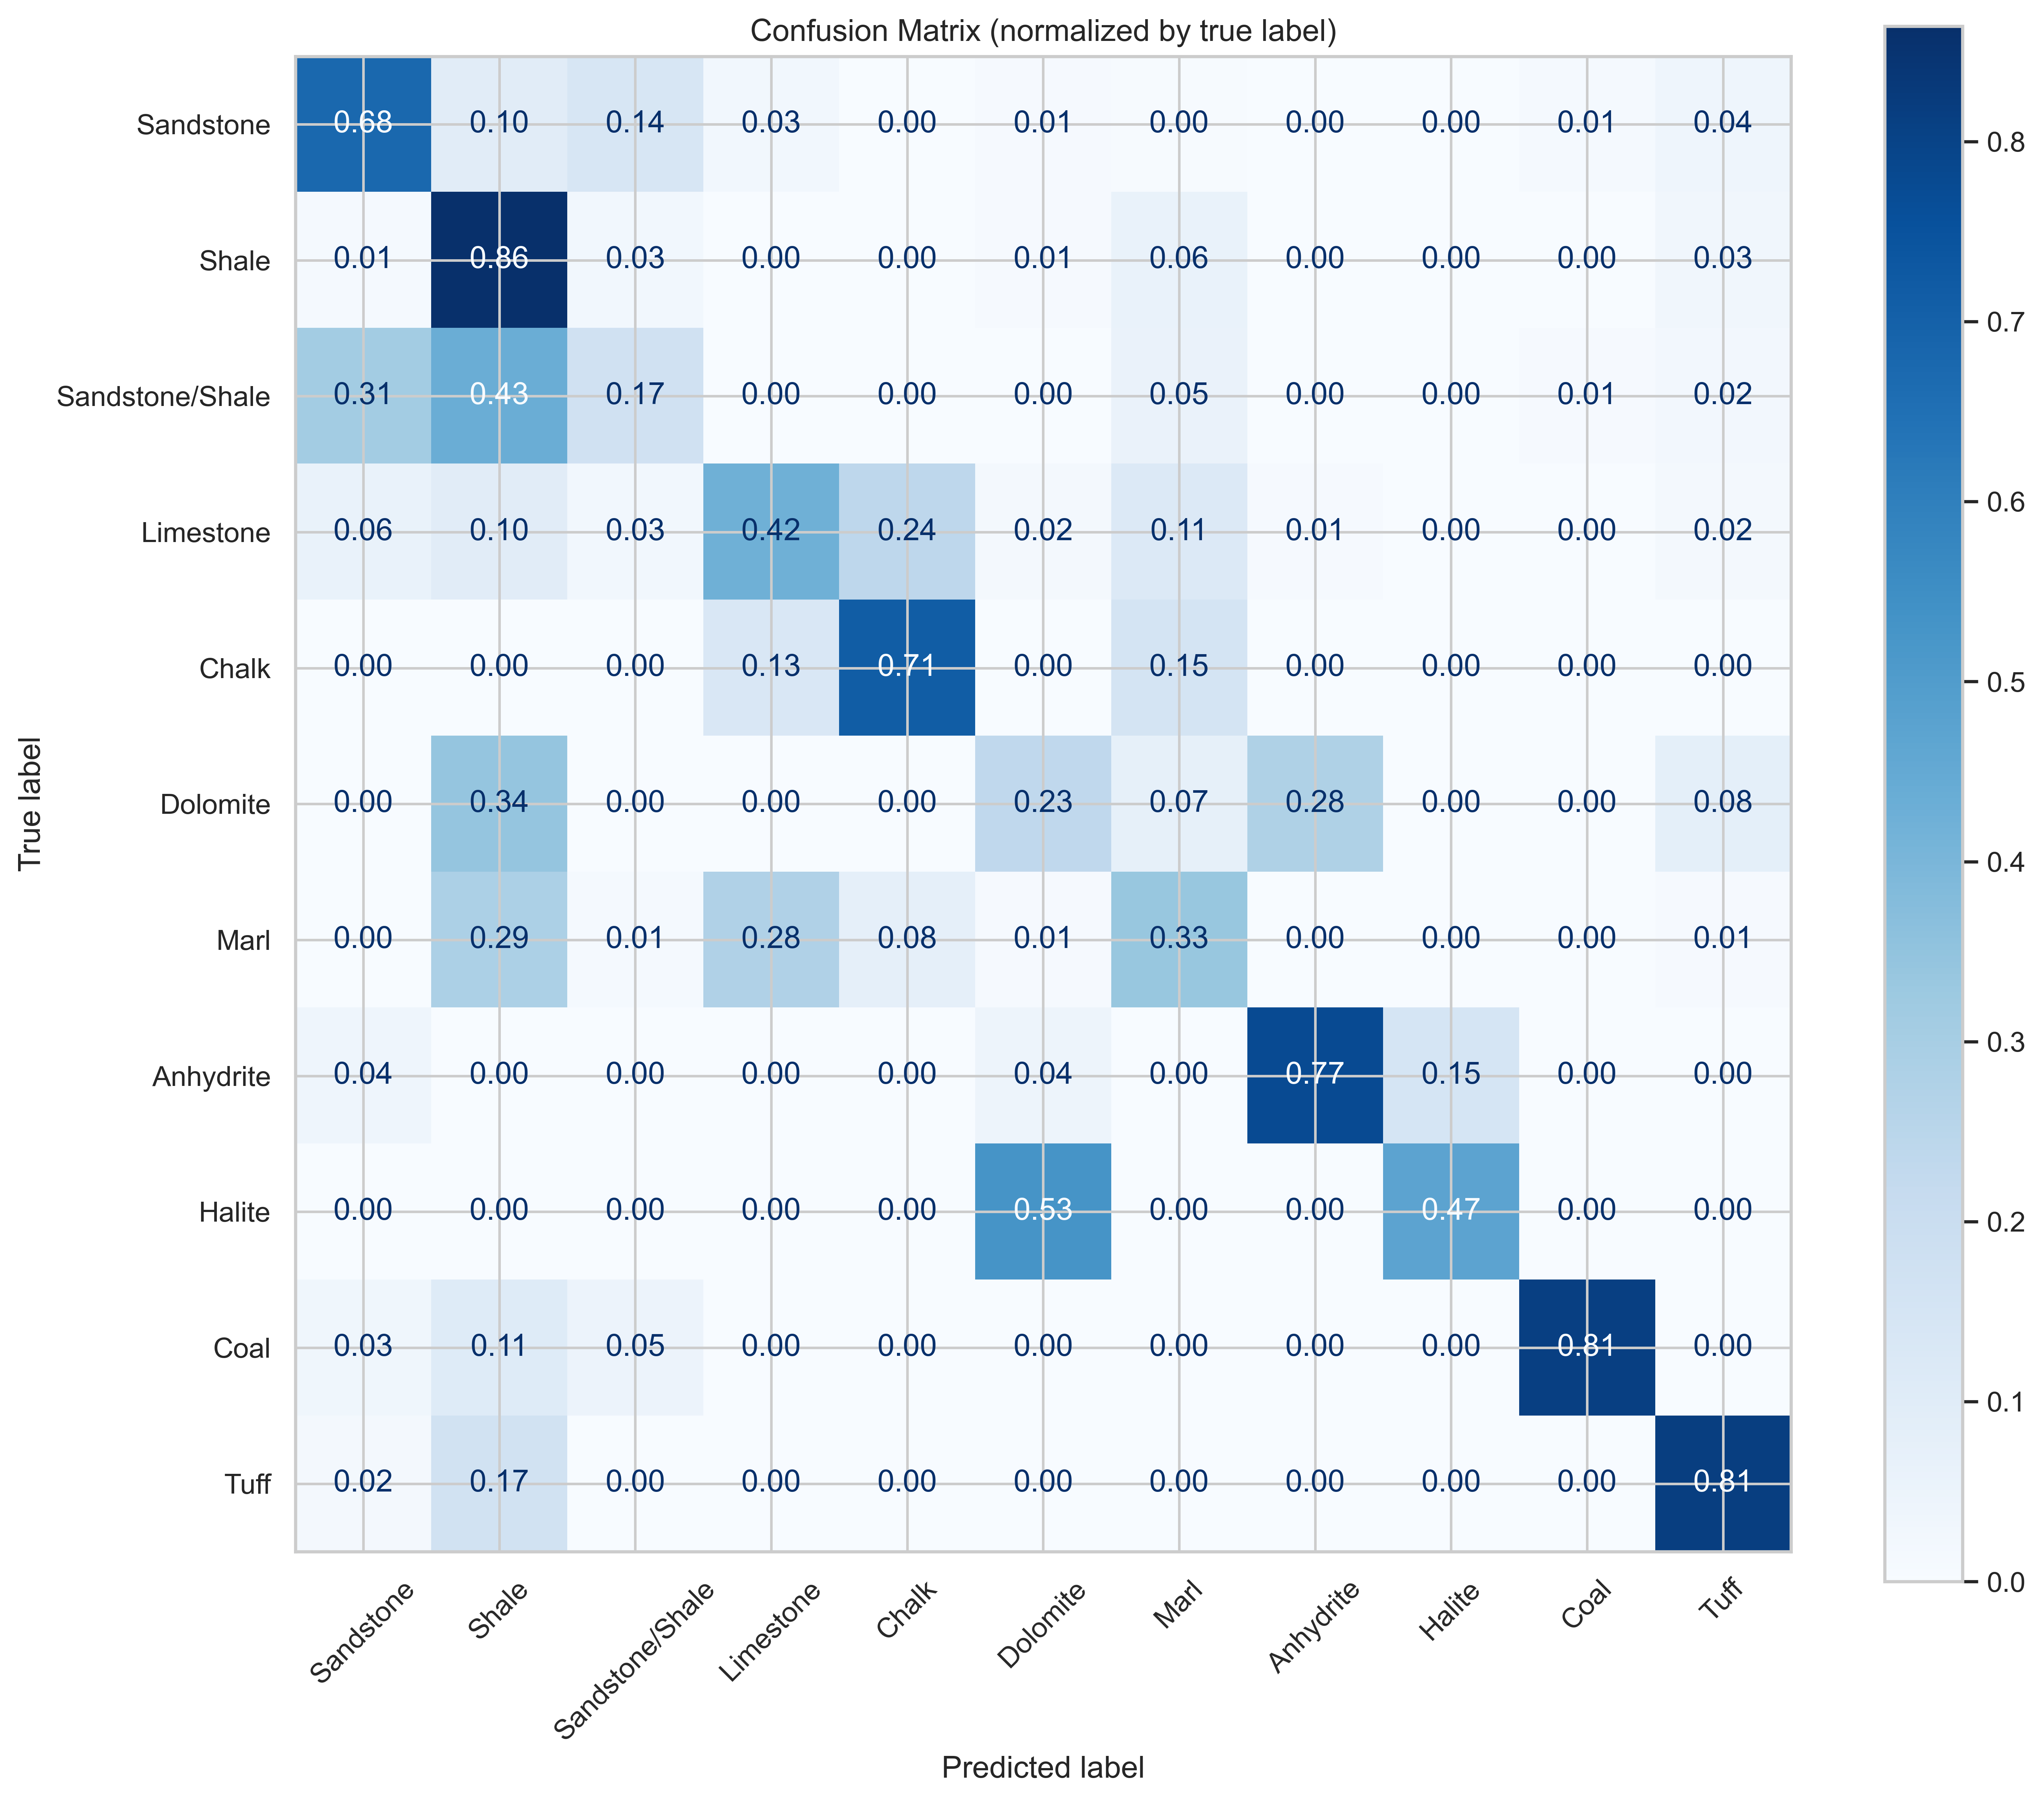

ROC-AUC графики сохранены в: /Users/polina/VSCode/ML/Lithology_project/Lithology prediction/reports/figures/dae_baseline_test/roc_auc_curves.png


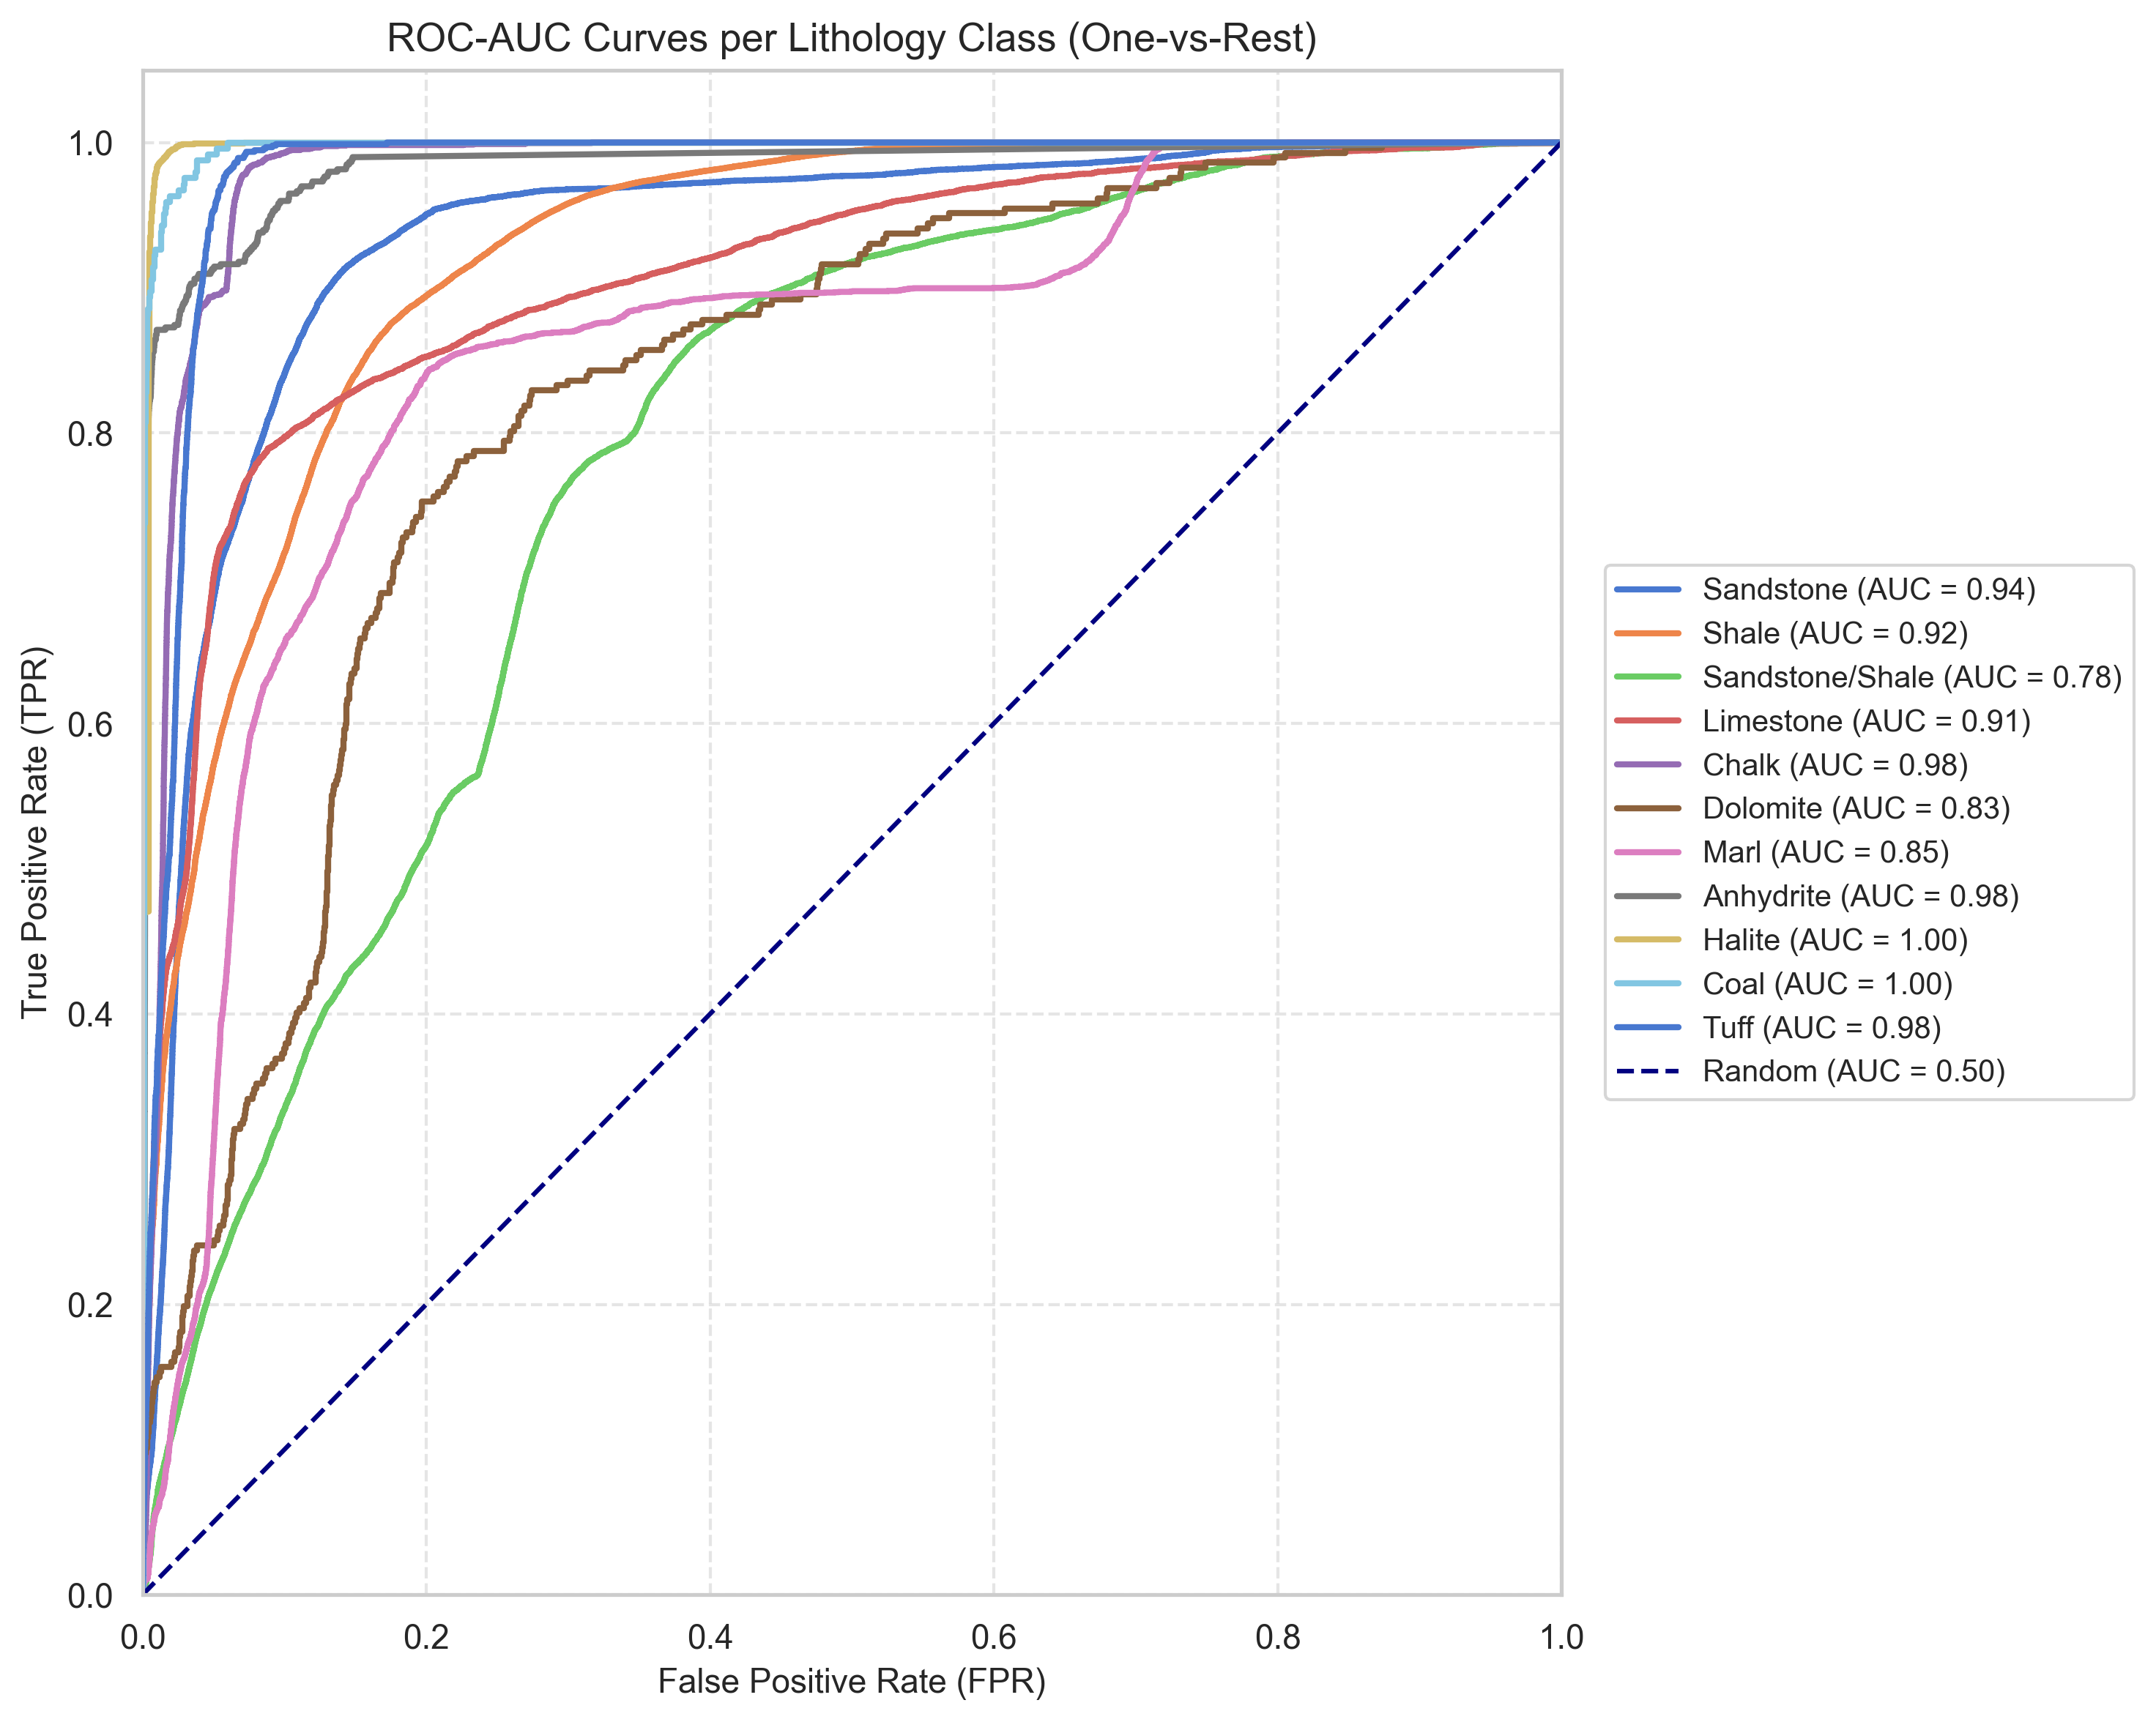

In [10]:
trainer = Baseline(test_size=0.2, random_state=42)
trainer.fit_eval(df_full_train_final)

test_preds = trainer.predict(df_test_final)
test_probs = trainer.predict_proba(df_test_final)
from sklearn.metrics import classification_report
print(classification_report(df_test_dae['FORCE_2020_LITHOFACIES_LITHOLOGY'], test_preds))

evaluator = LithologyEvaluator()
evaluator.plot_all(
    y_true=df_test_dae['FORCE_2020_LITHOFACIES_LITHOLOGY'],
    y_pred=test_preds, val_probs=test_probs,
    classes=trainer.pipeline.classes_,
    output_dir=str(BASE_DIR / "reports" / "figures" / "dae_baseline_test"),
)